***2023  Creator: Yetkin Aslan***

# Theory Of Evolution Simulation - Evrim Teorisinin Simülasyonu Projesi

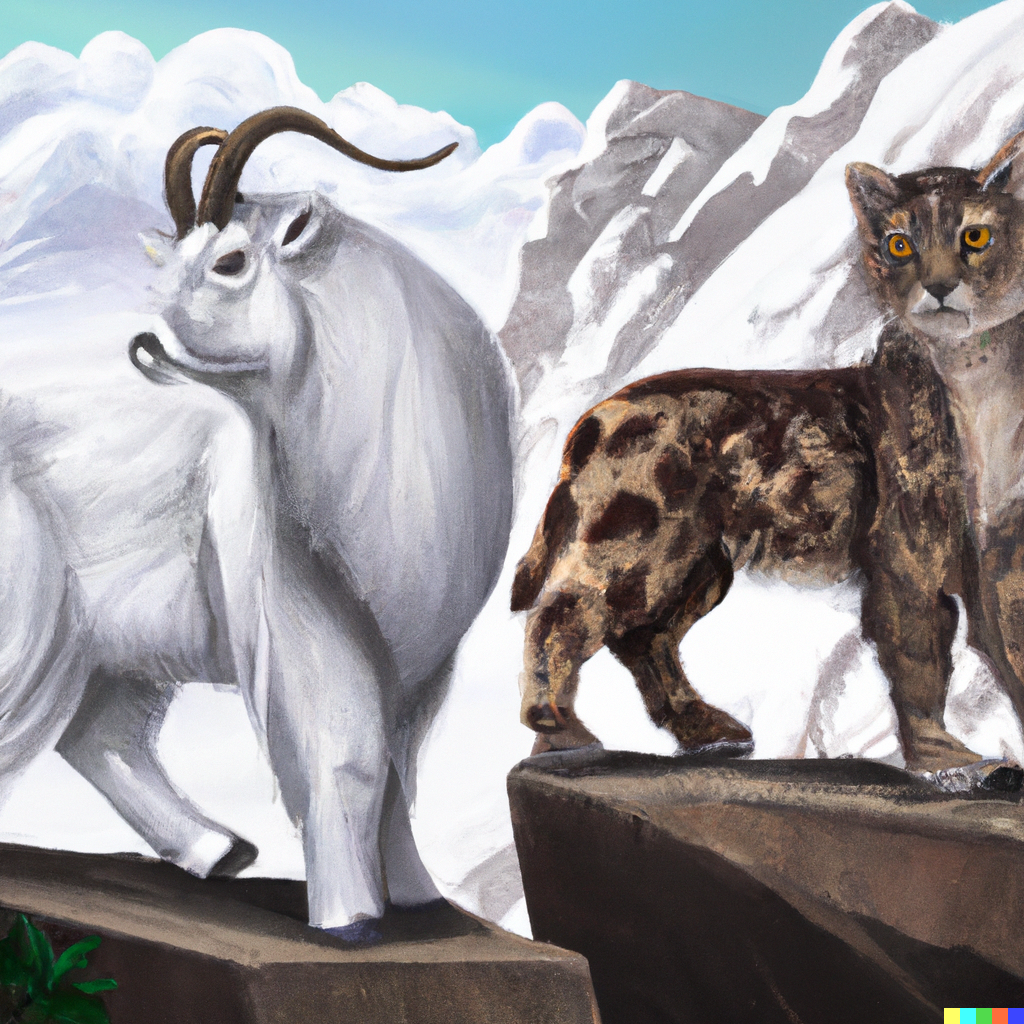

Bu proje, makine öğrenimi yöntemlerini kullanarak canlıların nasıl evrimleştiğini simüle eden bilimsel bir çalışmadır. Kitap, projenin aşama aşama raporu niteliğindedir. 

## Proje hakkında kısa bir bilgilendirme

Bu projenin ana fikri, küçük bir habitatta bulunan birbiri ile ilişkili iki canlının evrim sürecini simüle edip gözlemlemektir.
Canlıların zaman içerisinde geçirdiği bütün değişiklikler veri olarak toplanamayacağı için, örneklem üzerinde çalışılmaktadır.

Keçi ve Kar Leoparlarının akrabası sayılabilecek canlıların yaşadığı ortamlara göre hangi evrimsel süreçlerden geçtiği göz önüne alınarak, ortam koşulları ve av-avcı ilişkisi değişiklikleriyle meydana gelen değişimlere göre hayatta kalma oranları bir makine öğrenme modeli ile tahmin edilecektir. Size bir örnek sunayım:

**Örnek:** Kırsal bir habitatta, albino keçilerin; normal keçilere ne oranla hayatta kaldıklarının tespiti yapılır.(Albino keçi yerine başka bir tür beyaz keçi kullanılsaydı, sadece renk yerine diğer özellikler de hayatta kalma oranını etkileyecekti) 
Kırsal alanda beyaz keçiler, koyu renkli keçilere göre daha zor kamufle oldukları için; hayatta kalma oranları daha düşük (avlanma olasılıkları daha yüksek olacak) olduğunu biliyoruz. Başlangıçta kırsal kesime koyulan belirli bir sayıdaki beyaz keçilerin mutasyon geçirip değişik renklere sahip olduğunu göreceğiz. Mutasyon kalıcı olduğu için, keçiler ürediğinde çocukları da onlarla aynı renge sahip olacaktır. Ve sonuç olarak beyaz renkli keçi sürüsünün koyu renkli keçi sürüsüne dönüştüğünü göreceğiz.
Bu uygulama farklı habitatlarda farklı özellikler için de yapılacaktır. Bu süre zafında neler olduğunu bilgisayar ortamında gözlemleyebileceğiz.

## Bu videoyu izleyin:
Play On:  [YouTube](https://www.youtube.com/watch?v=0ZGbIKd0XrM)

# Adımlar

## Adım 1: Bilimsel Nitelikte Bir Veri Seti Oluşturma

### Özellikler

Bir hayvanın hayatta kalabilme olasılığı onun fiziksel özellikleriyle doğru orantılıdır. 

**1.Renk**

Renk, hayvanın yaşadığı habitatla uyum göstermesi halinde sıcaklık farklarından koruma, kamuflaj sağlama, iletişim sağlama (örneğin anne keçi yavrusu albinoysa onu kabullenmeyebilir) gibi avantaj sağlar. Habitatlara göre hayvanın rengi hayatta kalma olasığını net bir biçimde etkilemektedir. Bizim yarattığımız doğal şartlarda hayvanın rengi onun için en önemli unsur olacaktır.
Bu konu hakkında şu kaynağı takip edebilirsiniz: https://evrimagaci.org/albinizm-albino-ve-melanizm-hayvanlarda-normalden-farkli-renkte-olmanin-bedeli-7881


**2.Hareket Kabiliyeti**

Avcılardan kaçınmak için hareketli olmak ya da kendini savunabilmek gerekir.

**3. Kaynaklarla Yetinebilme**

Besin, oksijen ve su kullanımının hayatta kalma olasılığı üzerindeki etkisi tartışılamaz.

### Genetik özellikleri basit bir biçimde kodlama

Canlıların özellikleri, genlerine bağlıdır. Derine inmeden yüzeysel bir şekilde bunları kodlamamız gerekir. Örneğin keçi beyaz renkli ise A geni, oyuk toynaklıysa Z geni, ciğer kapasitesi büyükse Q geni bulundursun. Bu keçinin genetiğini AZQ diye kodlayalım. Canlı mutasyona uğradığında çocuğunun genini BZQ olarak kodlayabiliriz. Hadi bir tablo oluşturalım.

In [87]:
import pandas as pd

renkler = ['koyu', 'açık', 'değişken']
toynak = ['esnek', 'sert', 'geniş']
ckap = ['yüksek', 'ortalama', 'alçak']
tbesin = ['taze ot', 'taze ot ve dikenler', 'taze ot, diken ve böcek']
boynuz = ['var - küçük','var - sürekli gelişen', 'yok']

renklerkod = ['[1,0,0]','[0,1,0]','[0,0,1]']
toynakkod = ['[1,0,0]', '[0,1,0]', '[0,0,1]']
ckapkod = ['[1,0,0]', '[0,1,0]','[0,0,1]']
tbesinkod = ['[1,0,0]', '[0,1,0]', '[0,0,1]']
boynuzkod = ['[1,0,0]', '[0,1,0]', '[0,0,1]']
tablo = pd.DataFrame({"Renkler": renkler, "Toynak Şekli": toynak, "Ciğer Kapasitesi": ckap, "Beslenme Türü": tbesin, "Boynuz": boynuz,"Renk Kodu": renklerkod, "Toynak Kodu": toynakkod, "Ciğer Kapasitesi Kodu": ckapkod, "Besin Türü Kodu":tbesinkod, "Boynuz Kodu": boynuzkod})
tablo

,Renkler,Toynak Şekli,Ciğer Kapasitesi,Beslenme Türü,Boynuz,Renk Kodu,Toynak Kodu,Ciğer Kapasitesi Kodu,Besin Türü Kodu,Boynuz Kodu
0,koyu,esnek,yüksek,taze ot,var - küçük,"[1,0,0]","[1,0,0]","[1,0,0]","[1,0,0]","[1,0,0]"
1,açık,sert,ortalama,taze ot ve dikenler,var - sürekli gelişen,"[0,1,0]","[0,1,0]","[0,1,0]","[0,1,0]","[0,1,0]"
2,değişken,geniş,alçak,"taze ot, diken ve böcek",yok,"[0,0,1]","[0,0,1]","[0,0,1]","[0,0,1]","[0,0,1]"


Bu tabloya göre koyu renkli, geniş toynaklı, ortalama ciğer kapasiteli, sadece otla beslenen ve boynuzu olmayan bir keçinin gen kodu 13213 olacaktır. Bu kodun özelliklerini öğrenmek için bir fonksiyon yazacağız.

Bu özelliklere göre bir hayatta kalma oranı tablosu oluşturalım. İstatistiksel verilerden yararlanarak habitata ve genlere bağlı hayatta kalma verilerini içeren csv dosyamızı import edelim. Daha sonra kolaylık sağlaması açısından,  A geni 1, B geni 2, C geni 3 olarak ifade edilecektir.

In [3]:
columns = ["Renk", "Toynak", "Ciğer Kapasitesi", "Beslenme Türü", "Boynuz", "Hayatta Kalma Oranı"]
# Alpler Habitatı
alphkoran = pd.DataFrame(data = pd.read_csv("alplerhabitat.csv"))
alphkoran

,Renk,Toynak,Ciğer Kapasitesi,Beslenme Türü,Boynuz,Hayatta Kalma Oranı
0,1,1,1,1,1,50
1,3,1,2,2,3,70
2,3,1,1,3,1,95
3,2,1,3,2,2,60
4,2,3,2,1,3,40
5,2,1,1,1,1,80
6,1,2,3,3,2,30
7,1,2,2,2,2,25


Veri setimizi oluşturduğumuza göre, üzerinde çalışmaya başlayabiliriz.

## 2. Veri Görselleştirme

#### Kütüphanelerimizi import edelim.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<BarContainer object of 8 artists>

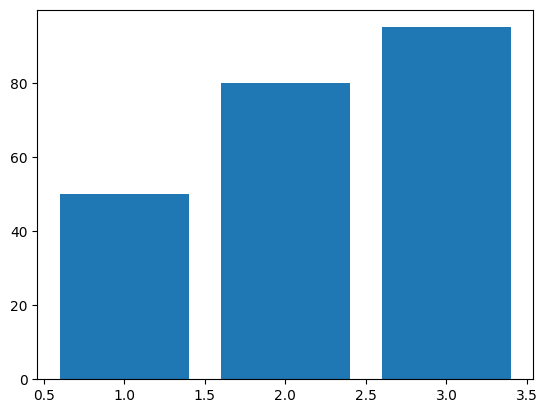

In [6]:
# Renge Göre Hayatta kalma

plt.bar(alphkoran["Renk"], alphkoran["Hayatta Kalma Oranı"])

Değişken renkli keçilerin açık renkli keçilere, açık renklilerin koyu renklilere oranla daha yüksek bir hayatta kalma oranı olduğunu söyleyebiliriz.

Bunun sebebi alpler habitatının genellikle karlı ve beyaz renkte olması olabilir. Keçiler daha iyi kamufle oluyor ve avcılarından kaçıyor olabilir.

## 3. Model Oluşturma

Modelimizi oluşturmaya başlayalım. Önce kütüphanelerimizi import edip, verilerimizi hazır hale getirelim.

In [26]:
y = alphkoran["Hayatta Kalma Oranı"]

mapping = {
    1: [1, 0, 0],
    2: [0, 1, 0],
    3: [0, 0, 1]
}

x = alphkoran.drop("Hayatta Kalma Oranı", axis=1)

x = x.map(lambda v: mapping.get(v, v))

x
            

,Renk,Toynak,Ciğer Kapasitesi,Beslenme Türü,Boynuz
0,"[1, 0, 0]","[1, 0, 0]","[1, 0, 0]","[1, 0, 0]","[1, 0, 0]"
1,"[0, 0, 1]","[1, 0, 0]","[0, 1, 0]","[0, 1, 0]","[0, 0, 1]"
2,"[0, 0, 1]","[1, 0, 0]","[1, 0, 0]","[0, 0, 1]","[1, 0, 0]"
3,"[0, 1, 0]","[1, 0, 0]","[0, 0, 1]","[0, 1, 0]","[0, 1, 0]"
4,"[0, 1, 0]","[0, 0, 1]","[0, 1, 0]","[1, 0, 0]","[0, 0, 1]"
5,"[0, 1, 0]","[1, 0, 0]","[1, 0, 0]","[1, 0, 0]","[1, 0, 0]"
6,"[1, 0, 0]","[0, 1, 0]","[0, 0, 1]","[0, 0, 1]","[0, 1, 0]"
7,"[1, 0, 0]","[0, 1, 0]","[0, 1, 0]","[0, 1, 0]","[0, 1, 0]"


In [32]:
import torch

x_tensor = torch.tensor(x.values.tolist(), dtype=torch.float32).view(-1, 15)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

print(f'shape of x_tensor: {x_tensor.shape}')
print(f'shape of y_tensor: {y_tensor.shape}')

weights = torch.randn((15, 1), requires_grad=True)
bias = torch.randn(1, requires_grad=True)
learning_rate = 0.1
for epoch in range(1000):
    y_pred = torch.matmul(x_tensor, weights) + bias
    loss = torch.mean((y_pred - y_tensor) ** 2)
    
    loss.backward()
    
    with torch.no_grad():
        weights -= learning_rate * weights.grad
        bias -= learning_rate * bias.grad
        
        weights.grad.zero_()
        bias.grad.zero_()
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')
print(f'Epoch {epoch}, Loss: {loss.item()}')
def predict_survival(features):
    features_tensor = torch.tensor(features, dtype=torch.float32)
    with torch.no_grad():
        prediction = torch.matmul(features_tensor, weights) + bias
    return prediction.item()

shape of x_tensor: torch.Size([8, 15])
shape of y_tensor: torch.Size([8, 1])
Epoch 0, Loss: 3365.9853515625
Epoch 100, Loss: 1.886427879333496
Epoch 200, Loss: 0.5968540906906128
Epoch 300, Loss: 0.2702086567878723
Epoch 400, Loss: 0.1261424571275711
Epoch 500, Loss: 0.0590117983520031
Epoch 600, Loss: 0.02761099487543106
Epoch 700, Loss: 0.012919215485453606
Epoch 800, Loss: 0.006044743116945028
Epoch 900, Loss: 0.0028283707797527313
Epoch 999, Loss: 0.0013334575342014432


In [34]:
# Örnek tahmin
example_features = torch.tensor([[0,1,0],[0,1,0],[0,1,0],[0,1,0],[0,1,0]], dtype=torch.float32).view(-1, 15)
predicted_survival = predict_survival(example_features)
print(f'Predicted Survival Rate: {predicted_survival}')

Predicted Survival Rate: 54.916259765625


C:\Users\Yetkin\AppData\Local\Temp\ipykernel_26008\3358621671.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_tensor = torch.tensor(features, dtype=torch.float32)


## Modeli Değerlendirmek

In [42]:
def whichgoat(code):
    if len(code) != 5:
        raise ValueError("Kod 5 karakter uzunluğunda olmalıdır.")

    tmp = ""

    for l in code:
        match l:
            case [1, 0, 0]:
                tmp += '1'
            case [0, 1, 0]:
                tmp += '2'
            case [0, 0, 1]:
                tmp += '3'
            case _:
                raise ValueError(f"Geçersiz kod: {l}")

    code = list(tmp)

    print("Renk:", tablo.loc[tablo["Renk Kodu"] == code[0], "Renkler"].iloc[0])
    print("Toynak:", tablo.loc[tablo["Toynak Kodu"] == code[1], "Toynak Şekli"].iloc[0])
    print("Ciğer Kapasitesi:", tablo.loc[tablo["Ciğer Kapasitesi Kodu"] == code[2], "Ciğer Kapasitesi"].iloc[0])
    print("Beslenme Türü:", tablo.loc[tablo["Besin Türü Kodu"] == code[3], "Beslenme Türü"].iloc[0])
    print("Boynuz:", tablo.loc[tablo["Boynuz Kodu"] == code[4], "Boynuz"].iloc[0])

whichgoat([[0,1,0],[0,1,0],[0,1,0],[0,1,0],[0,1,0]]);        

Renk: açık
Toynak: sert
Ciğer Kapasitesi: ortalama
Beslenme Türü: taze ot ve dikenler
Boynuz: var - sürekli gelişen


Bir kaç deneme yapıp modelimizin mantıklı sonuçlar verip vermeyeceğini görebiliriz. Alpler habitatında yaşayan keçiler değişken renkli, esnek toynaklı, yüksek ciğer kapasiteli, taze ot, diken ve böcek yiyebilen, küçük boynuzlu keçilerdir. Hayatta kalma oranlarının yüksek olması gerekir. Hadi tahmini görelim

In [45]:
goat = [[0,0,1],[1,0,0],[1,0,0],[0,0,1],[1,0,0]]
whichgoat(goat)

predict_survival(torch.tensor(goat).view(-1,15))


Renk: değişken
Toynak: esnek
Ciğer Kapasitesi: yüksek
Beslenme Türü: taze ot, diken ve böcek
Boynuz: var - küçük


C:\Users\Yetkin\AppData\Local\Temp\ipykernel_26008\3358621671.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_tensor = torch.tensor(features, dtype=torch.float32)


95.035888671875

Yüzde ~95 hayatta kalma oranı ile gayet mantıklı bir model eğittimizi görebiliyoruz.

## Teorik Simülasyon

Hadi bir habitat yaratıp keçilerin dönüşüp dönüşmeyeceğini görelim.

In [53]:
import random

def creategoat():
    goatcode = []

    for _ in range(5):
        v = [0, 0, 0]
        idx = random.randint(0, 2)
        v[idx] = 1
        goatcode.append(v)

    return goatcode



In [54]:
creategoat()

[[0, 0, 1], [0, 1, 0], [0, 0, 1], [0, 1, 0], [1, 0, 0]]

Elimizde CBCBA genetiğinde bir keçi oldu. Habitata 100 keçi yerleştirelim ve keçilerin fenotipini görelim.

In [55]:
habitat = []
goattype = creategoat()
for i in range(100):
    habitat.append(goattype)
habitat

[[[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [

Elimizde BAACB genetiğinde 100 tane keçi mevcut. Onlara mutasyon geçirtelim. İşlerin çabuk olması açısından her gün 10 keçi ölsün ve 10 keçi mutasyon geçirip doğum yapsın. Ama öncelikle bunları bir tabloda gösterelim.

In [58]:
import pandas as pd

def create_table(habitat):
    keys = list(map(str, habitat))
    table = pd.DataFrame([pd.Series(keys).value_counts()])
    return table

        


In [59]:
create_table(habitat)

,"[[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]]"
count,100


Bu fonksiyon bize habitatta hangi genetiğe sahip kaç keçi var, onu gösterecek. Hadi mutasyon fonksiyonumuzu yazalım.

In [79]:
# Mutasyonları rastgele, ölümleri hayatta kalma olasılığına bağlı seçeceğiz.
import random
import copy


def mutate_individual(ind, n_mutations=1):
    ind = copy.deepcopy(ind)

    for _ in range(n_mutations):
        gene_idx = random.randint(0, len(ind)-1)
        new_gene = [0, 0, 0]
        new_gene[random.randint(0, 2)] = 1
        ind[gene_idx] = new_gene

    return ind


def mutation(population, p_mut=0.3):
    new_population = []

    for ind in population:
        if random.random() < p_mut:
            new_population.append(mutate_individual(ind))
        else:
            new_population.append(copy.deepcopy(ind))

    return new_population

    

In [80]:
create_table(habitat)

,"[[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]]"
count,100


### Hayatta kalma oranlarına göre hayvan ölüm - doğumları

Popülasyonu sabit varsayılan bir keçi grubunda hayatta kalma oranına göre ölüm - doğum eşitliği çerçevesinde bir fonksiyon yazalım.

In [83]:

def nextday(habitat, pop_size=None):
    if pop_size is None:
        pop_size = len(habitat)

    # 1. Mutation
    population = mutation(habitat)

    # 2. Fitness hesapla
    fitness = [predict_survival(torch.tensor(ind).view(-1,15)) for ind in population]

    # 3. Selection (roulette-wheel)
    survivors = []
    for ind, fit in zip(population, fitness):
        if random.random() < fit / 100:
            survivors.append(ind)

    # Eğer herkes elendiyse en iyiyi koru
    if not survivors:
        survivors.append(population[fitness.index(max(fitness))])

    # 4. Reproduction
    next_population = copy.deepcopy(survivors)
    while len(next_population) < pop_size:
        parent = random.choice(survivors)
        next_population.append(parent.copy())

    return next_population

            
    
       

In [82]:
nextday(habitat)

torch.Size([100, 5, 3])


C:\Users\Yetkin\AppData\Local\Temp\ipykernel_26008\3358621671.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_tensor = torch.tensor(features, dtype=torch.float32)


[[[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [0, 0, 1], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]],
 [[0, 1, 0], [

nextday fonksiyonunu 100000 kere çalıştıralım.

In [ ]:
# Ben burayı çalıştırdım, çok fazla uzun sürüyor ve gereksiz çıktı veriyor, aşağıdaki kodların çalıştığını bilerek incelemeye devam edin.
for i in range(1, 100000):
    habitat =nextday(habitat)
    if i%1000 == 0:
        print(f"%{i / 1000:.1f}")


In [534]:
pd.set_option('display.max_columns', None)

In [89]:
GENES = {
    "Renk": {
        0: "koyu",
        1: "açık",
        2: "değişken"
    },
    "Toynak Şekli": {
        0: "esnek",
        1: "sert",
        2: "geniş"
    },
    "Ciğer Kapasitesi": {
        0: "yüksek",
        1: "ortalama",
        2: "alçak"
    },
    "Beslenme Türü": {
        0: "taze ot",
        1: "taze ot ve dikenler",
        2: "taze ot, diken ve böcek"
    },
    "Boynuz": {
        0: "var - küçük",
        1: "var - sürekli gelişen",
        2: "yok"
    }
}


In [91]:
import pandas as pd
import numpy as np

def habitat_statistics(habitat):
    records = []

    for gene_idx, (gene_name, categories) in enumerate(GENES.items()):
        gene_vectors = np.array([ind[gene_idx] for ind in habitat])
        counts = gene_vectors.sum(axis=0)

        for cat_idx, cat_name in categories.items():
            records.append({
                "Gen": gene_name,
                "Özellik": cat_name,
                "Adet": int(counts[cat_idx])
            })

    return pd.DataFrame(records)
stats = habitat_statistics(habitat)
print(stats)
stats_pivot = stats.pivot(index="Gen", columns="Özellik", values="Adet").fillna(0).astype(int)
stats_pivot

                 Gen                  Özellik  Adet
0               Renk                     koyu     3
1               Renk                     açık    38
2               Renk                 değişken    59
3       Toynak Şekli                    esnek    80
4       Toynak Şekli                     sert    14
5       Toynak Şekli                    geniş     6
6   Ciğer Kapasitesi                   yüksek    80
7   Ciğer Kapasitesi                 ortalama    14
8   Ciğer Kapasitesi                    alçak     6
9      Beslenme Türü                  taze ot    16
10     Beslenme Türü      taze ot ve dikenler    13
11     Beslenme Türü  taze ot, diken ve böcek    71
12            Boynuz              var - küçük    85
13            Boynuz    var - sürekli gelişen    11
14            Boynuz                      yok     4


Özellik,alçak,açık,değişken,esnek,geniş,koyu,ortalama,sert,taze ot,taze ot ve dikenler,"taze ot, diken ve böcek",var - küçük,var - sürekli gelişen,yok,yüksek
Gen,,,,,,,,,,,,,,,
Beslenme Türü,0,0,0,0,0,0,0,0,16,13,71,0,0,0,0
Boynuz,0,0,0,0,0,0,0,0,0,0,0,85,11,4,0
Ciğer Kapasitesi,6,0,0,0,0,0,14,0,0,0,0,0,0,0,80
Renk,0,38,59,0,0,3,0,0,0,0,0,0,0,0,0
Toynak Şekli,0,0,0,80,6,0,0,14,0,0,0,0,0,0,0


Değişken ve açık renkli keçilerin ezici bir çoğunlukta olduğunu ve çoğalmakta olduğunu görüyoruz.
İşlem tamamlandığında 3 numaralı renk geninin ve diğer genlerde hayatta kalma oranını yükselten gen sayısında artış olduğunu görüyoruz. Bu, zayıf formlardan güçlü formlara kesin bir geçiş olduğu anlamına gelmektedir. Türlerin daha iyi opsiyonlarına evrimleştiğini (tamamen bir simülasyon olsa da) gözlemlemiş olduk.


Projeye Göz Gezdirdiğin İçin Teşekkürler!

**`2023 - Yetkin Aslan`**